## Random Forest (Classificação) — SPI / Income

**Objetivo**: prever a classe `income` (rendimento) a partir das features do dataset `spi_indicators.csv`.

Este notebook documenta, em **Python (scikit-learn)**, a construção de um modelo de classificação com **Random Forest**, cobrindo todo o fluxo de trabalho:

1. Carregamento e separação treino/teste (com estratificação)
2. Pré-processamento (sem escalonamento, imputação, one-hot e clipping leve de outliers)
3. Especificação do modelo (Random Forest)
4. Validação cruzada e ajuste de hiperparâmetros
5. Treinamento final e análise de importância das features
6. Avaliação final no conjunto de teste

Observação: no scikit-learn, `ccp_alpha` implementa poda por complexidade de custo (cost-complexity pruning).

In [1]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 123

## Etapa 1 — Carregamento e Separação dos Dados

Nesta etapa o dataset `spi_indicators.csv` é carregado e a variável alvo `income` é tratada como **categórica**.

Em seguida, o conjunto de dados é dividido em **treino (70%)** e **teste (30%)** com **estratificação**, preservando a proporção das classes em ambos os subconjuntos. O conjunto de teste é mantido separado para avaliação final.

In [2]:
# Ajuste o caminho caso o notebook seja executado a partir de outro diretório.
# Como o CSV está na raiz do repositório, o caminho relativo mais simples é "../spi_indicators.csv".

df = pd.read_csv("../spi_indicators.csv")

# (Opcional, mas comum no dataset SPI) remover linhas sem classe definida.
# No repositório há um trecho equivalente que remove 'Not classified'.
if "income" in df.columns:
    df = df[df["income"].ne("Not classified")].copy()

# Definições
TARGET = "income"  # alvo categórico
DROP_COLS = ["iso3c", "country"]  # identificadores que não devem entrar no modelo

# X/y
X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET].astype("category")

# Split 70/30 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Shape total:", df.shape)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Classes:", list(y.cat.categories))
print("Distribuição (treino):")
print(y_train.value_counts(normalize=True).round(3))

Shape total: (4320, 12)
Treino: (3024, 9) Teste: (1296, 9)
Classes: ['High income', 'Low income', 'Lower middle income', 'Upper middle income']
Distribuição (treino):
income
High income            0.394
Upper middle income    0.250
Lower middle income    0.236
Low income             0.120
Name: proportion, dtype: float64


## Etapa 2 — Pré-processamento (Pipeline)

Esta etapa constrói o pipeline de pré-processamento com `ColumnTransformer`, separando variáveis **numéricas** e **categóricas**.

Regras adotadas:

- **Sem escalonamento**: modelos baseados em árvores não dependem de padronização/normalização.
- **Encoding**: variáveis categóricas são convertidas via **one-hot encoding**.
- **Tratamento leve de outliers**: variáveis numéricas passam por *clipping* por quantis (1% e 99%), com limites aprendidos apenas no treino.

Transformações aplicadas:

- **Numéricas**: imputação por mediana + clipping por quantis.
- **Categóricas**: imputação pelo valor mais frequente + one-hot encoding.

O resultado desse pipeline é utilizado como entrada do modelo de classificação.

In [3]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """Clipping leve de outliers por quantis (por coluna).

    - Aprende limites (low/high) no fit
    - Aplica np.clip no transform

    Útil como 'tratamento leve de outliers' sem escalonamento.

    Nota: implementa `get_feature_names_out` para ser compatível com
    `ColumnTransformer.get_feature_names_out()`.
    """

    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.low, axis=0)
        self.upper_ = np.nanquantile(X, self.high, axis=0)

        # Para compatibilidade com get_feature_names_out
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            # fallback genérico (evita quebrar, mas o ideal é passar nomes)
            return np.array([f"x{i}" for i in range(self.n_features_in_)], dtype=object)
        return np.asarray(input_features, dtype=object)


# Separar colunas por tipo
numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clip", QuantileClipper(low=0.01, high=0.99)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

Numéricas: ['year', 'population', 'overall_score', 'data_use_score', 'data_services_score', 'data_products_score', 'data_sources_score', 'data_infrastructure_score']
Categóricas: ['region']


## Etapa 3 — Especificação do Modelo (Random Forest — Classificação)

Nesta etapa é definido o modelo **Random Forest** para classificação.

Configurações principais:

- O modelo é acoplado ao pipeline de pré-processamento (Etapa 2) via `Pipeline`.
- `class_weight="balanced"` é utilizado para mitigar efeitos de desbalanceamento entre classes.
- Parâmetros estruturais (ex.: `min_samples_leaf`, `max_depth`) controlam complexidade das árvores.

Os hiperparâmetros relevantes do Random Forest (incluindo `ccp_alpha`) são ajustados na validação cruzada (Etapa 4).

In [4]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced",  # ajuda quando as classes não são perfeitamente balanceadas
    min_samples_leaf=5,
    max_depth=None,
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("rf", rf),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## Etapa 4 — Validação Cruzada e Ajuste de Hiperparâmetros (Tuning)

Esta etapa executa validação cruzada **estratificada (10 folds)** no conjunto de treino e ajusta hiperparâmetros do Random Forest via `GridSearchCV`.

Hiperparâmetros avaliados (exemplos):

- `rf__ccp_alpha`: poda por complexidade de custo (cost-complexity pruning)
- `rf__max_features`: quantidade de features candidatas por split
- `rf__n_estimators`: número de árvores na floresta

Métricas registradas:

- **Acurácia (accuracy)**
- **ROC AUC multiclasses** (`roc_auc_ovr_weighted`)

Ao final, o melhor conjunto de hiperparâmetros é selecionado conforme o critério definido em `refit`.

In [5]:
# Grid inicial (enxuto) para manter o tempo de execução razoável.
# Você pode refinar depois (mais pontos de ccp_alpha, mais combinações etc.).
param_grid = {
    "rf__ccp_alpha": [0.0, 0.0005, 0.001, 0.005],
    "rf__max_features": ["sqrt", 0.5, None],
    "rf__n_estimators": [300, 600],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "roc_auc_ovr_weighted": "roc_auc_ovr_weighted",
    },
    refit="accuracy",  # escolhe o melhor pelo critério principal
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_).sort_values(by="rank_test_accuracy")
results[["param_rf__ccp_alpha", "param_rf__max_features", "param_rf__n_estimators", "mean_test_accuracy", "mean_test_roc_auc_ovr_weighted"]].head(10)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


C:\Users\j.franciscon\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,param_rf__ccp_alpha,param_rf__max_features,param_rf__n_estimators,mean_test_accuracy,mean_test_roc_auc_ovr_weighted
4,0.0000,None,300,0.859464,0.978776
5,0.0000,None,600,0.859129,0.978855
10,0.0005,None,300,0.856485,0.977284
11,0.0005,None,600,0.856485,0.977439
17,0.0010,None,600,0.846897,0.975342
16,0.0010,None,300,0.846565,0.975186
3,0.0000,0.5,600,0.836983,0.973816
2,0.0000,0.5,300,0.834671,0.973741
9,0.0005,0.5,600,0.831027,0.972017
8,0.0005,0.5,300,0.828719,0.971908


## Etapa 5 — Treinamento Final e Análise de Importância das Features

Nesta etapa, o modelo com melhor desempenho na validação cruzada é re-treinado utilizando **100% do conjunto de treino**.

Como forma de interpretação do modelo, é calculada e exibida a **importância das features** (`feature_importances_`) do Random Forest. Também é apresentado um gráfico com as top features mais relevantes segundo esse critério.

Melhores hiperparâmetros (CV/accuracy):
{'rf__ccp_alpha': 0.0, 'rf__max_features': None, 'rf__n_estimators': 300}
Melhor accuracy (CV): 0.8594638602933141


,feature,importance
0,num__population,0.340043
1,cat__region_Sub-Saharan Africa,0.194589
2,num__data_products_score,0.188365
3,num__data_sources_score,0.047014
4,num__data_infrastructure_score,0.042810
5,num__data_use_score,0.036111
6,cat__region_Latin America & Caribbean,0.031746
7,cat__region_Europe & Central Asia,0.031320
8,num__year,0.025602
9,cat__region_South Asia,0.014520


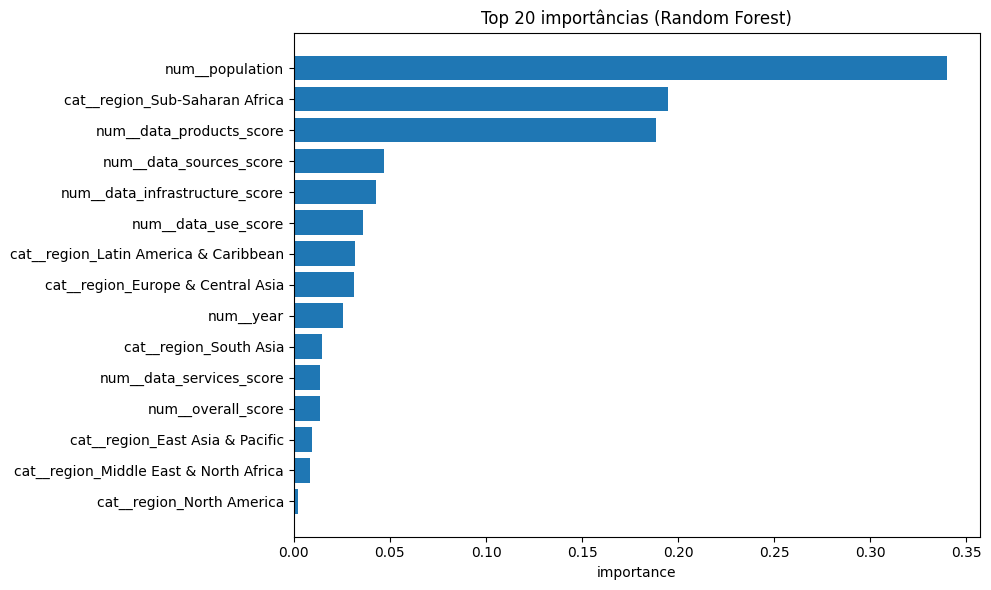

In [6]:
print("Melhores hiperparâmetros (CV/accuracy):")
print(grid.best_params_)
print("Melhor accuracy (CV):", grid.best_score_)

final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

# Importância das features
pre = final_model.named_steps["preprocess"]
rf_fitted = final_model.named_steps["rf"]

feature_names = pre.get_feature_names_out()
importances = rf_fitted.feature_importances_

imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(imp.head(20))

plt.figure(figsize=(10, 6))
plt.barh(imp.loc[:19, "feature"][::-1], imp.loc[:19, "importance"][::-1])
plt.title("Top 20 importâncias (Random Forest)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

## Etapa 6 — Avaliação Final no Conjunto de Teste

Nesta etapa o modelo final é aplicado ao conjunto de teste (holdout) mantido separado na Etapa 1.

Métricas e análises produzidas:

- **Matriz de confusão** para inspeção de acertos/erros por classe
- **Acurácia** no conjunto de teste
- **Relatório de classificação** (precision/recall/F1 por classe)
- **ROC AUC multiclasses (OVR weighted)** a partir de `predict_proba` (quando aplicável)

Esses resultados representam a estimativa de desempenho do modelo em dados não vistos.

Acurácia (teste): 0.8672839506172839

Relatório de classificação:

                     precision    recall  f1-score   support

        High income       0.93      0.91      0.92       510
         Low income       0.71      0.90      0.79       156
Lower middle income       0.90      0.77      0.83       306
Upper middle income       0.85      0.87      0.86       324

           accuracy                           0.87      1296
          macro avg       0.85      0.86      0.85      1296
       weighted avg       0.87      0.87      0.87      1296



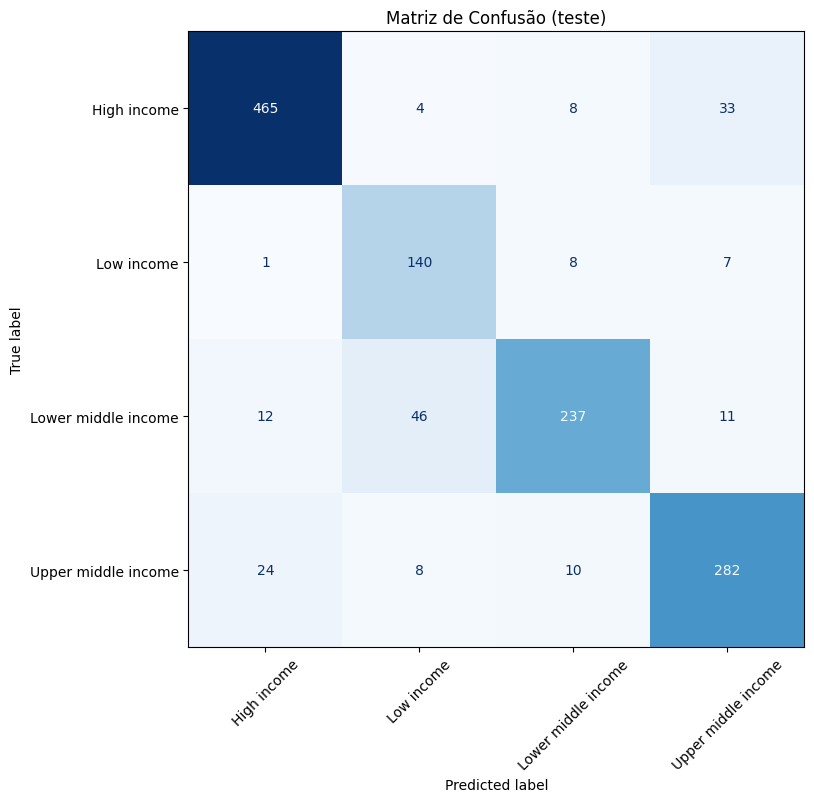

ROC AUC (OVR weighted, teste): 0.980499029765182


In [ ]:
y_pred = final_model.predict(X_test)

a = accuracy_score(y_test, y_pred)
print("Acurácia (teste):", a)
print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=y_train.cat.categories)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_train.cat.categories)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão (teste)")
plt.show()

# ROC AUC multiclasses (OVR weighted)
try:
    proba = final_model.predict_proba(X_test)
    auc = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")
    print("ROC AUC (OVR weighted, teste):", auc)
except Exception as e:
    print("Não foi possível calcular ROC AUC (detalhes abaixo):")
    print(e)

# Ajuda a ter uma noção de generalização sem usar o teste.
if hasattr(final_model.named_steps["rf"], "oob_score_"):
    print("OOB score:", final_model.named_steps["rf"].oob_score_)

In [8]:
import os
import joblib

os.makedirs("../clfs", exist_ok=True)

MODEL_PATH = "../clfs/random_forest_income.pkl"
joblib.dump(final_model, MODEL_PATH)

print("Modelo salvo em:", os.path.abspath(MODEL_PATH))

Modelo salvo em: c:\Estudos\UFABC\Machine Learning\Projeto Final\Aprendizado-de-maquina-job\clfs\random_forest_income.pkl
